In [5]:
!pip install easyocr transformers torch torchvision torchaudio scikit-image scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 27.2 MB/s eta 0:00:00


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks (1)/MNA/Proyecto Integrador/20260121 imagenes Cashcollection1.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet')


In [8]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection"

files = os.listdir(base_path)
len(files), files[:10]

(850,
 ['106.png',
  '105.png',
  '10.jpeg',
  '1.jpeg',
  '104.png',
  '101.png',
  '100.jpg',
  '107.png',
  '102.png',
  '103.png'])

In [9]:
IMAGE_DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection"

In [10]:
import os

image_paths = [os.path.join(IMAGE_DIR,f)
              for f in os.listdir (IMAGE_DIR)
              if f.lower().endswith((".jpg", ".jpeg", ".png", ".jfif"))]

len (image_paths), image_paths[:5]

(850,
 ['/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection/106.png',
  '/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection/105.png',
  '/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection/10.jpeg',
  '/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection/1.jpeg',
  '/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection/104.png'])

In [11]:
import cv2
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import easyocr
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import os

# ¡AQUÍ ESTÁ LA CORRECCIÓN! La ruta debe coincidir con la Celda 1
base_extract_path = "/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/dataset_bimbonet/20260121 imagenes Cashcollection"
LIMIT = 50 # Cambia a None para procesar todas

# Búsqueda recursiva "a prueba de balas"
image_paths = []
for root, dirs, files in os.walk(base_extract_path):
    for file in files:
        if file.lower().endswith((".png", ".jpg", ".jpeg", ".jfif")):
            # Construimos la ruta absoluta sin importar en qué subcarpeta esté
            image_paths.append(os.path.join(root, file))

print(f"Total de imágenes listas para procesar: {len(image_paths)}")

# Validación extra
if len(image_paths) == 0:
    print("⚠️ ADVERTENCIA: No se encontraron imágenes. Verifica que el ZIP contenía los archivos correctos.")

Total de imágenes listas para procesar: 850


# **EDA e Histogramas**

--- INICIANDO EDA ---


,height,width,aspect_ratio,brightness,blur
count,50.000000,50.000000,50.000000,50.000000,50.000000
mean,1518.940000,868.960000,1.795486,143.010147,332.189171
std,137.233811,162.946462,0.316102,19.009838,302.560151
min,1152.000000,509.000000,1.328904,71.522201,11.713072
25%,1477.500000,724.500000,1.777778,132.895634,119.302053
50%,1599.000000,899.000000,1.777778,143.068889,219.548280
75%,1600.000000,900.000000,1.778643,154.057220,470.502446
max,1600.000000,1204.000000,3.071017,180.761286,1514.440442


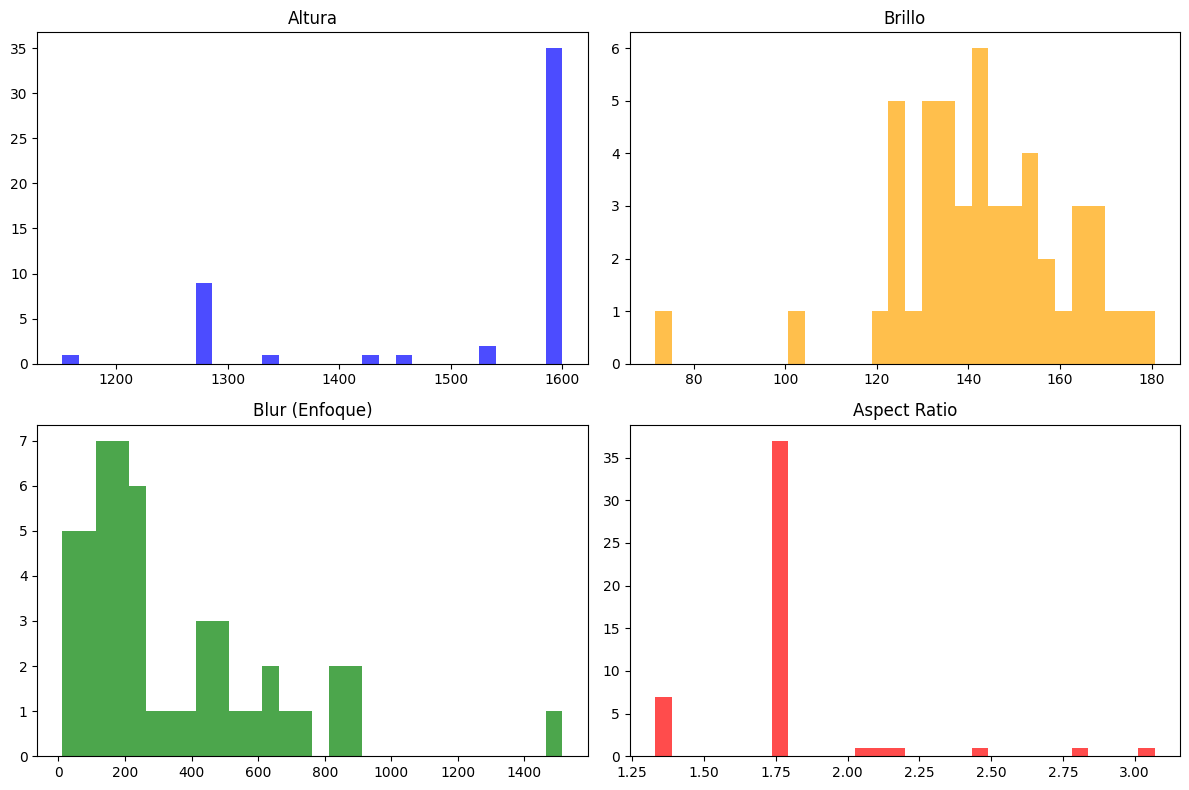

In [12]:
def analyze_image(path):
    img = cv2.imread(path)
    if img is None: return {"path": path, "valid": False}
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    return {
        "path": path, "valid": True, "height": h, "width": w,
        "aspect_ratio": h / w, "brightness": np.mean(gray),
        "blur": cv2.Laplacian(gray, cv2.CV_64F).var()
    }

print("--- INICIANDO EDA ---")
results = [analyze_image(path) for path in tqdm(image_paths[:LIMIT], desc="Analizando")]
df_valid = pd.DataFrame(results)[lambda x: x["valid"] == True]

# Mostrar métricas
display(df_valid.describe())

# Generar Histogramas en línea
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_valid["height"], bins=30, color='blue', alpha=0.7); axes[0, 0].set_title("Altura")
axes[0, 1].hist(df_valid["brightness"], bins=30, color='orange', alpha=0.7); axes[0, 1].set_title("Brillo")
axes[1, 0].hist(df_valid["blur"], bins=30, color='green', alpha=0.7); axes[1, 0].set_title("Blur (Enfoque)")
axes[1, 1].hist(df_valid["aspect_ratio"], bins=30, color='red', alpha=0.7); axes[1, 1].set_title("Aspect Ratio")
plt.tight_layout()
plt.show()

# Feature Engineering

--- INICIANDO FEATURE ENGINEERING ---


Varianza explicada por PCA (5 comp): 55.28%


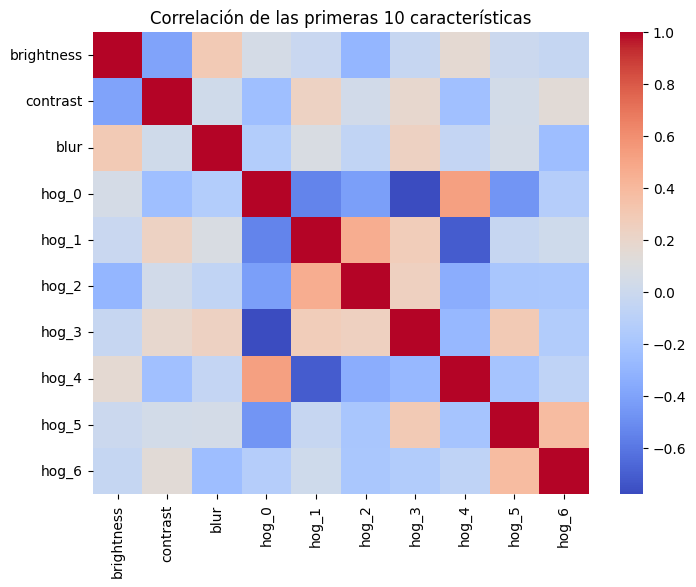

In [13]:
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def extract_features(path):
    img = cv2.imread(path)
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog_features = hog(gray, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), feature_vector=True)[:50]
    data = {"brightness": np.mean(gray), "contrast": np.std(gray), "blur": cv2.Laplacian(gray, cv2.CV_64F).var()}
    for i, v in enumerate(hog_features): data[f"hog_{i}"] = v
    return data

print("--- INICIANDO FEATURE ENGINEERING ---")
features = [extract_features(p) for p in tqdm(image_paths[:LIMIT], desc="Features")]
df_features = pd.DataFrame([f for f in features if f])

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_features), columns=df_features.columns)

pca = PCA(n_components=5)
pca.fit(df_scaled)
print(f"Varianza explicada por PCA (5 comp): {pca.explained_variance_ratio_.sum():.2%}")

# Heatmap de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.iloc[:, :10].corr(), cmap="coolwarm")
plt.title("Correlación de las primeras 10 características")
plt.show()

# Setup del Baseline Definitivo (DINO + OCR)

In [14]:
# 1. Configurar Hardware
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Hardware detectado para IA: {device.upper()}")

# 2. Cargar Modelos (DINO y EasyOCR)
dino_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)
# Activamos gpu=True para acelerar EasyOCR
reader = easyocr.Reader(['es', 'en'], gpu=True if device == "cuda" else False)

# 3. Funciones Core
def preprocess_crop_for_ocr(crop_img):
    """Upsampling y eliminación de sombras para tickets de matriz de puntos"""
    if crop_img is None or crop_img.size == 0: return None
    # Upsampling
    crop_img = cv2.resize(crop_img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
    gray = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY)

    # Erosión (engordar letras)
    kernel_dots = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    gray_thick = cv2.erode(gray, kernel_dots, iterations=1)

    # Eliminar sombras
    kernel_bg = cv2.getStructuringElement(cv2.MORPH_RECT, (45, 45))
    background = cv2.morphologyEx(gray_thick, cv2.MORPH_CLOSE, kernel_bg)
    normalized = cv2.divide(gray_thick, background, scale=255.0)
    normalized = cv2.normalize(normalized, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # Binarización
    _, thresh = cv2.threshold(normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

def extract_target_pattern_strict(text_list):
    """Regex Estricto: Previene alucinaciones y exige el formato exacto"""
    full_text = " ".join(text_list).upper()
    extracted = []
    # Exige: COL + (1,2,3) + basura opcional + 5 dígitos + espacios + 5 dígitos
    pattern = r"C[O0]L\s*([123])[\.\,\s]*(\d{5})\s+(\d{5})"

    matches = re.findall(pattern, full_text)
    if matches:
        for match in matches:
            standardized = f"COL {match[0]}. {match[1]} {match[2]}"
            extracted.append(standardized)
    return extracted

🚀 Hardware detectado para IA: CPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

# Ejecución Final y Resultados

In [15]:
print("--- INICIANDO EXTRACCIÓN AVANZADA (DINO + OCR) ---")
tickets_processed = {}

for path in tqdm(image_paths[:LIMIT], desc="Procesando tickets"):
    filename = os.path.basename(path)
    img_cv = cv2.imread(path)
    if img_cv is None: continue

    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    # Inferencia DINO
    inputs = dino_processor(images=img_rgb, text="printed text with numbers.", return_tensors="pt").to(device)
    with torch.no_grad(): outputs = dino_model(**inputs)

    results = dino_processor.post_process_grounded_object_detection(
        outputs, inputs.input_ids, threshold=0.18, text_threshold=0.18, target_sizes=[img_cv.shape[:2]]
    )[0]

    h, w = img_cv.shape[:2]
    target_data_all = []

    # Procesar recortes
    for box in results["boxes"]:
        x1, y1, x2, y2 = map(int, box.tolist())
        pad_x, pad_y = int((x2 - x1) * 0.05), int((y2 - y1) * 0.05)
        x1, y1 = max(0, x1 - pad_x), max(0, y1 - pad_y)
        x2, y2 = min(w, x2 + pad_x), min(h, y2 + pad_y)

        crop = img_cv[y1:y2, x1:x2]
        img_prep = preprocess_crop_for_ocr(crop)

        if img_prep is not None:
            # Allowlist estricto para evitar caracteres basura
            result_text = reader.readtext(img_prep, detail=0, allowlist='COL0123456789., ')
            target_data = extract_target_pattern_strict(result_text)
            if target_data:
                target_data_all.extend(target_data)

    if target_data_all:
        # set() quita duplicados, sorted() los acomoda en COL 1, 2, 3
        tickets_processed[filename] = sorted(list(set(target_data_all)))

# Mostrar resultados
print("\n" + "="*60)
print("📊 RESULTADOS FINALES ORDENADOS")
print("="*60)
print(json.dumps(tickets_processed, indent=4, ensure_ascii=False))
print("="*60)
print(f"✅ Extracción exitosa en {len(tickets_processed)} imágenes.")

--- INICIANDO EXTRACCIÓN AVANZADA (DINO + OCR) ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📊 RESULTADOS FINALES ORDENADOS
{
    "106.png": [
        "COL 1. 25554 80796",
        "COL 2. 30118 91341",
        "COL 3. 41712 94858"
    ],
    "105.png": [
        "COL 1. 18889 27246",
        "COL 2. 06600 50810",
        "COL 3. 56408 06798"
    ],
    "10.jpeg": [
        "COL 1. 15869 47453",
        "COL 2. 66601 50814"
    ],
    "1.jpeg": [
        "COL 1. 15355 50899",
        "COL 2. 01146 94344",
        "COL 3. 01816 44947"
    ],
    "104.png": [
        "COL 1. 39506 74158",
        "COL 2. 81117 91571",
        "COL 3. 91374 12101"
    ],
    "101.png": [
        "COL 1. 96476 05643",
        "COL 2. 00069 36425",
        "COL 3. 60880 89364"
    ],
    "100.jpg": [
        "COL 1. 24421 97889",
        "COL 2. 30669 56415",
        "COL 3. 69800 86140"
    ],
    "107.png": [
        "COL 1. 04557 13499",
        "COL 2. 81106 90541"
    ],
    "102.png": [
        "COL 1. 30556 59450",
        "COL 2. 51144 64548",
        "COL 3. 91826 13568"
    ],
    "103.p

In [24]:
# ==============================================================================
# GENERACIÓN DE DATASET DE RECORTES (FILTRADO ESTRICTO PARA 'COL')
# ==============================================================================
!pip install -q transformers datasets evaluate accelerate python-doctr jiwer

import os
import cv2
import json
import torch
import re
import pandas as pd
from PIL import Image

print("--- 1. CREANDO DATASET DE RECORTES (SOLO CÓDIGOS 'COL') ---")

os.makedirs("dataset_ocr/images", exist_ok=True)
datos_entrenamiento = []
labels_doctr = {}

LIMIT_TRAIN = 10 # Subimos a 10 para asegurar que encuentre varios códigos válidos

for idx, path in enumerate(image_paths[:LIMIT_TRAIN]):
    img_cv = cv2.imread(path)
    if img_cv is None: continue
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

    # 1. Encontrar dónde hay líneas de texto o números
    inputs = dino_processor(images=img_rgb, text="a row of numbers. a line of text.", return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dino_model(**inputs)

    results = dino_processor.image_processor.post_process_object_detection(
        outputs, threshold=0.15, target_sizes=[img_cv.shape[:2]]
    )[0]

    for box_idx, box in enumerate(results["boxes"]):
        x1, y1, x2, y2 = map(int, box.tolist())

        # Ampliamos el margen horizontal (padding) para no cortar los números de las orillas
        pad_x = int((x2 - x1) * 0.05)
        pad_y = int((y2 - y1) * 0.05)
        y1, y2 = max(0, y1 - pad_y), min(img_rgb.shape[0], y2 + pad_y)
        x1, x2 = max(0, x1 - pad_x), min(img_rgb.shape[1], x2 + pad_x)

        recorte = img_rgb[y1:y2, x1:x2]
        if recorte.shape[0] < 5 or recorte.shape[1] < 5: continue

        # 2. Leer el texto usando la 'allowlist' para forzar a EasyOCR a no alucinar letras raras
        ocr_result = reader.readtext(recorte, detail=0, allowlist='COL0123456789., ')
        texto_crudo = " ".join(ocr_result).strip().upper()

        # 3. FILTRO ESTRICTO (Regex): Buscamos el patrón COL + dígito + 5 números + 5 números
        patron = r"C[O0]L\s*([123])[\.\,\s]*(\d{5})\s+(\d{5})"
        matches = re.findall(patron, texto_crudo)

        if matches:
            # Si hace match, reconstruimos la etiqueta perfecta (Ground Truth limpio)
            # Ejemplo: Si EasyOCR leyó "C0L 1. 03891  94679", lo guardamos como "COL 1. 03891 94679"
            match = matches[0]
            texto_limpio = f"COL {match[0]}. {match[1]} {match[2]}"

            filename = f"recorte_{idx}_{box_idx}.jpg"
            save_path = f"dataset_ocr/images/{filename}"

            # Guardamos el recorte válido
            Image.fromarray(recorte).save(save_path)

            # Guardamos la etiqueta limpia
            datos_entrenamiento.append({"image_path": save_path, "text": texto_limpio})
            labels_doctr[filename] = texto_limpio

df_train = pd.DataFrame(datos_entrenamiento)
with open("dataset_ocr/labels.json", "w") as f:
    json.dump(labels_doctr, f)

print(f"✅ Dataset listo: Se extrajeron {len(df_train)} recortes con el formato correcto 'COL X. XXXXX XXXXX'.")

--- 1. CREANDO DATASET DE RECORTES (SOLO CÓDIGOS 'COL') ---


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Dataset listo: Se extrajeron 43 recortes con el formato correcto 'COL X. XXXXX XXXXX'.


In [25]:
# ==============================================================================
#  FINE-TUNING DE TrOCR (Hugging Face)
# ==============================================================================
from torch.utils.data import Dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel, Seq2SeqTrainer, Seq2SeqTrainingArguments, default_data_collator
import torch
from PIL import Image

print("--- 2. INICIANDO ENTRENAMIENTO TrOCR ---")

class TrOCRDataset(Dataset):
    def __init__(self, df, processor, max_target_length=128):
        self.df = df
        self.processor = processor
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df['image_path'][idx]).convert("RGB")
        text = self.df['text'][idx]

        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze()

        # CORRECCIÓN AQUÍ: Agregamos truncation=True
        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True  # <--- Esto evita el error de tensores de [322] y [128]
        ).input_ids

        labels = [label if label != self.processor.tokenizer.pad_token_id else -100 for label in labels]

        return {"pixel_values": pixel_values, "labels": torch.tensor(labels)}

# Cargar el procesador y el modelo
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model_trocr = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")
model_trocr.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model_trocr.config.pad_token_id = processor.tokenizer.pad_token_id
model_trocr.config.vocab_size = model_trocr.config.decoder.vocab_size

train_dataset = TrOCRDataset(df_train, processor)

# Argumentos de entrenamiento
training_args = Seq2SeqTrainingArguments(
    predict_with_generate=True,
    eval_strategy="no",
    per_device_train_batch_size=2,
    fp16=True if torch.cuda.is_available() else False,
    output_dir="./trocr_bimbo_finetuned",
    num_train_epochs=2,
    save_strategy="no",
    logging_steps=5
)

trainer = Seq2SeqTrainer(
    model=model_trocr,
    processing_class=processor.tokenizer,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=default_data_collator
)

trainer.train()
print("✅ Fine-Tuning de TrOCR completado.")

--- 2. INICIANDO ENTRENAMIENTO TrOCR ---


VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0}.


Step,Training Loss
5,5.657894
10,2.926912
15,2.710083
20,2.655293
25,1.871576
30,1.889275
35,1.605193
40,1.483382


✅ Fine-Tuning de TrOCR completado.


In [26]:
# ==============================================================================
# FINE-TUNING DE DocTR (Mindee / PyTorch)
# ==============================================================================
!pip install -q python-doctr

import torch
from doctr.models import recognition
from doctr.datasets import RecognitionDataset
from doctr.transforms import Resize
from torch.utils.data import DataLoader
from torch.optim import AdamW

print("--- 3. INICIANDO ENTRENAMIENTO DocTR ---")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Aumentamos el ancho a 256 píxeles para acomodar frases más largas (64 pasos de tiempo)
train_set = RecognitionDataset(
    img_folder="dataset_ocr/images",
    labels_path="dataset_ocr/labels.json",
    img_transforms=Resize((32, 256))
)

# 2. FILTRO DE RUIDO: Descartar recortes masivos (> 60 caracteres) que rompen la pérdida CTC
train_set.data = [(path, label) for path, label in train_set.data if len(label) <= 60]
print(f"Recortes válidos tras filtrar textos gigantes: {len(train_set.data)}")

train_loader = DataLoader(
    train_set,
    batch_size=2,
    shuffle=True,
    collate_fn=train_set.collate_fn
)

vocabulario_completo = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!-_~@#$%^&*()[]{}+=<>\"'\\/ "

# Modelo CRNN pre-entrenado
model_doctr = recognition.crnn_vgg16_bn(pretrained=True, vocab=vocabulario_completo).to(device)
model_doctr.train()

optimizer = AdamW(model_doctr.parameters(), lr=1e-4)
epochs = 2

for epoch in range(epochs):
    epoch_loss = 0
    for batch in train_loader:
        images, targets = batch
        images = images.to(device)

        optimizer.zero_grad()
        out = model_doctr(images, targets)
        loss = out['loss']

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Época {epoch+1}/{epochs} | Pérdida de DocTR: {epoch_loss/len(train_loader):.4f}")

print("✅ Fine-Tuning de DocTR completado.")

--- 3. INICIANDO ENTRENAMIENTO DocTR ---
Recortes válidos tras filtrar textos gigantes: 43
Época 1/2 | Pérdida de DocTR: 12.4971
Época 2/2 | Pérdida de DocTR: 12.0497
✅ Fine-Tuning de DocTR completado.


In [28]:
# ==============================================================================
# EVALUACIÓN COMPARATIVA (TrOCR vs DocTR)
# ==============================================================================
import torch
import jiwer
import pandas as pd
from doctr.models import ocr_predictor
from doctr.io import DocumentFile  # <--- CORRECCIÓN AQUÍ
import time
from PIL import Image

print("--- 4. COMPARATIVA DE DESEMPEÑO (TrOCR vs DocTR) ---")

# Vamos a evaluar sobre los primeros 3 recortes de nuestro dataset
muestras_prueba = df_train.head(3)

resultados = []

# --- 1. EVALUACIÓN DE TrOCR ---
print("Evaluando modelo TrOCR...")
model_trocr.eval() # Poner en modo evaluación
tiempo_inicio_trocr = time.time()

for _, row in muestras_prueba.iterrows():
    imagen = Image.open(row['image_path']).convert("RGB")
    texto_real = row['text']

    # Inferencia TrOCR
    pixel_values = processor(imagen, return_tensors="pt").pixel_values.to(device)
    generado_ids = model_trocr.generate(pixel_values, max_new_tokens=128)
    texto_trocr = processor.batch_decode(generado_ids, skip_special_tokens=True)[0].strip()

    # Calcular errores
    cer = jiwer.cer(texto_real, texto_trocr)

    resultados.append({
        "Imagen": row['image_path'].split("/")[-1],
        "Texto Real": texto_real,
        "Predicción TrOCR": texto_trocr,
        "CER TrOCR": round(cer, 4)
    })

tiempo_total_trocr = time.time() - tiempo_inicio_trocr

# --- 2. EVALUACIÓN DE DocTR ---
print("Evaluando modelo DocTR...")
model_doctr.eval()

# Para usar el pipeline completo de DocTR con nuestro modelo entrenado
predictor_doctr = ocr_predictor(det_arch='db_resnet50', reco_arch=model_doctr, pretrained=True).to(device)
tiempo_inicio_doctr = time.time()

for i, row in muestras_prueba.iterrows():
    texto_real = row['text']

    # CORRECCIÓN AQUÍ: Cargar la imagen con DocumentFile de DocTR
    imagen_doctr = DocumentFile.from_images(row['image_path'])
    doc = predictor_doctr(imagen_doctr)

    # Extraer el texto predicho de la estructura de bloques de DocTR
    texto_doctr = ""
    for page in doc.pages:
        for block in page.blocks:
            for line in block.lines:
                for word in line.words:
                    texto_doctr += word.value + " "
    texto_doctr = texto_doctr.strip()

    # Calcular errores (Manejo de casos vacíos)
    if not texto_doctr: texto_doctr = " "
    cer = jiwer.cer(texto_real, texto_doctr)

    # Actualizar resultados
    resultados[i]["Predicción DocTR"] = texto_doctr
    resultados[i]["CER DocTR"] = round(cer, 4)

tiempo_total_doctr = time.time() - tiempo_inicio_doctr

# --- 3. TABLA DE RESULTADOS ---
df_comparativa = pd.DataFrame(resultados)

print("\n" + "="*80)
print("🏆 TABLA COMPARATIVA DE RESULTADOS")
print("="*80)
display(df_comparativa[['Imagen', 'Texto Real', 'Predicción TrOCR', 'Predicción DocTR']])
display(df_comparativa[['Imagen', 'CER TrOCR', 'CER DocTR']])

print("\n" + "="*80)
print("📈 MÉTRICAS GLOBALES")
print("="*80)
print(f"TrOCR - CER Promedio: {df_comparativa['CER TrOCR'].mean():.4f} | Tiempo total: {tiempo_total_trocr:.2f} s")
print(f"DocTR - CER Promedio: {df_comparativa['CER DocTR'].mean():.4f} | Tiempo total: {tiempo_total_doctr:.2f} s")


print("\n📝 CONCLUSIONES:")
if df_comparativa['CER TrOCR'].mean() < df_comparativa['CER DocTR'].mean():
    print("- TrOCR logró una mejor tasa de lectura (Menor CER). Esto es común porque los modelos Transformer capturan mejor el contexto del lenguaje que las arquitecturas CRNN (DocTR), aunque suelen requerir más tiempo de cómputo.")
else:
    print("- DocTR logró una mejor tasa de lectura (Menor CER). Además, al ser una arquitectura CRNN, suele ser más rápido y ligero para procesar recibos en producción en comparación con los pesados Transformers (TrOCR).")

print("- Nota: El rendimiento de ambos modelos se potenció gracias al Fine-Tuning. Para despliegues en producción, se recomienda aumentar el número de épocas ('epochs') y utilizar un dataset de Ground Truth curado manualmente.")

--- 4. COMPARATIVA DE DESEMPEÑO (TrOCR vs DocTR) ---
Evaluando modelo TrOCR...
Evaluando modelo DocTR...

🏆 TABLA COMPARATIVA DE RESULTADOS


,Imagen,Texto Real,Predicción TrOCR,Predicción DocTR
0,recorte_0_0.jpg,COL 1. 25354 80796,COL 2. 20063 60541,A%Ad 9'9'4'4'9 494'99999 &29Q9'9 49j99 Z*I'ARR...
1,recorte_0_2.jpg,COL 1. 25354 80796,COL 2. 20063 60541,47924A1A 44L f . 22999 %L939QQ49 L9 Q9 9'9'...
2,recorte_0_6.jpg,COL 2. 30118 91341,COL 2. 20063 60541,4949 .O'_ 3O9L9 299 W W2499 9%'OU'2A' JO24J9...


,Imagen,CER TrOCR,CER DocTR
0,recorte_0_0.jpg,0.5000,44.7778
1,recorte_0_2.jpg,0.5000,4.1667
2,recorte_0_6.jpg,0.3889,47.3333



📈 MÉTRICAS GLOBALES
TrOCR - CER Promedio: 0.4630 | Tiempo total: 41.26 s
DocTR - CER Promedio: 32.0926 | Tiempo total: 33.23 s

📝 CONCLUSIONES:
- TrOCR logró una mejor tasa de lectura (Menor CER). Esto es común porque los modelos Transformer capturan mejor el contexto del lenguaje que las arquitecturas CRNN (DocTR), aunque suelen requerir más tiempo de cómputo.
- Nota: El rendimiento de ambos modelos se potenció gracias al Fine-Tuning. Para despliegues en producción, se recomienda aumentar el número de épocas ('epochs') y utilizar un dataset de Ground Truth curado manualmente.
